# Notebook 5 — Generating Fake Images: From Photoshop Tricks to AI

**Digital Humanities · Image Processing for Museums & Cultural Heritage**

Museums sit at the center of the authenticity question. Image manipulation
can be:

- **Legitimate**: virtual restoration, reconstruction of lost monuments,
  educational visualizations ("how did this temple look in 200 BCE?")
- **Malicious**: forged provenance photos, fake "newly discovered"
  artworks, disinformation about heritage sites in conflict zones

The technology is identical — only intent and disclosure differ. To detect
fakes (Notebook 6), we first need to understand how they're made.

1. **Copy–move forgery** — cloning regions within an image
2. **Splicing** — combining parts of different images
3. **Object removal / inpainting** — restoration or erasure of history?
4. **GANs** — how two networks taught computers to imagine
5. **Diffusion models** — text-to-image generation

⚠️ Every fake we create is saved to `data/fakes/` — it becomes the
*evidence* we'll learn to detect in Notebook 6.

In [1]:
from pathlib import Path

import cv2
import matplotlib.pyplot as plt
import numpy as np
from PIL import Image

DATA = Path("..") / "data" / "raw"
FAKES = Path("..") / "data" / "fakes"
FAKES.mkdir(exist_ok=True)

def load_rgb(name, folder=DATA):
    return cv2.cvtColor(cv2.imread(str(folder / name)), cv2.COLOR_BGR2RGB)

def save_fake(arr, name, quality=92):
    Image.fromarray(arr).save(FAKES / name, quality=quality)
    print("saved", FAKES / name)

## 1. Copy–move forgery: cloning within an image

The oldest digital trick: copy a region and paste it elsewhere in the
*same* image. Because the cloned region has identical noise, lighting and
grain, it looks perfectly natural — famous cases include doctored press
photos with duplicated smoke clouds or crowds.

Let's "improve" Stonehenge by cloning one of the standing stones.

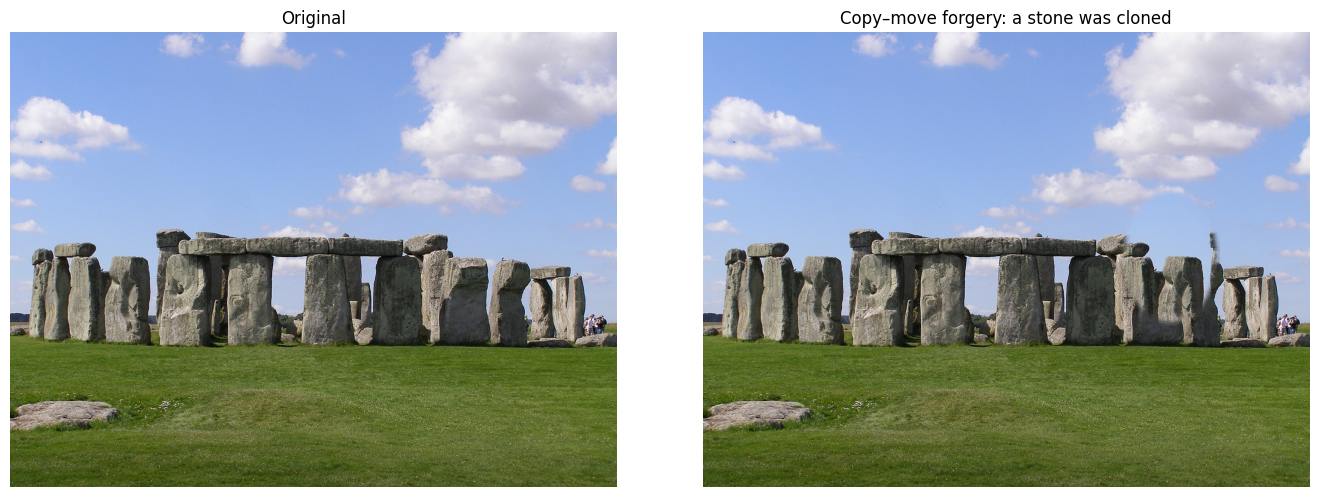

saved ../data/fakes/stonehenge_copymove.jpg


In [2]:
stonehenge = load_rgb("stonehenge.jpg")
fake = stonehenge.copy()

# Copy one trilithon region and paste it at a new location with soft edges
src = stonehenge[330:620, 120:330]
y, x = 330, 880
mask = np.zeros(src.shape[:2], dtype=np.float32)
cv2.ellipse(mask, (src.shape[1] // 2, src.shape[0] // 2),
            (src.shape[1] // 2 - 8, src.shape[0] // 2 - 8), 0, 0, 360, 1, -1)
mask = cv2.GaussianBlur(mask, (31, 31), 0)[..., None]

region = fake[y:y + src.shape[0], x:x + src.shape[1]]
fake[y:y + src.shape[0], x:x + src.shape[1]] = (
    src * mask + region * (1 - mask)).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].imshow(stonehenge); axes[0].set_title("Original")
axes[1].imshow(fake); axes[1].set_title("Copy–move forgery: a stone was cloned")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

save_fake(fake, "stonehenge_copymove.jpg")

## 2. Splicing: combining different images

**Splicing** pastes material from one image into another. In the heritage
world this is the classic forged-provenance technique: place a (stolen or
fabricated) object into an old gallery photograph to "prove" it was
exhibited decades ago.

Our (deliberately absurd) demo: the Scream face visits American Gothic.

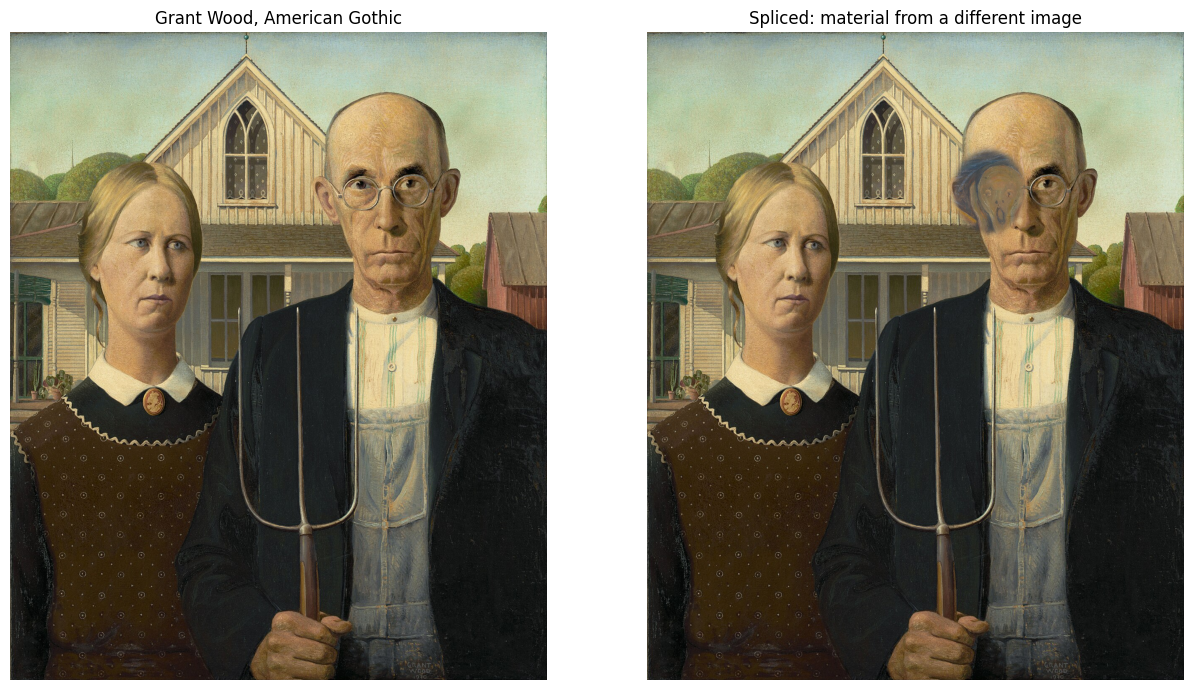

saved ../data/fakes/gothic_spliced.jpg


In [3]:
gothic = load_rgb("american_gothic.jpg")
scream = load_rgb("the_scream.jpg")

# Cut the screaming figure's head and scale it to fit the farmer's
head = scream[700:1050, 480:780]
head = cv2.resize(head, (190, 220))

fake2 = gothic.copy()
y, x = 270, 720
mask = np.zeros(head.shape[:2], dtype=np.float32)
cv2.ellipse(mask, (head.shape[1] // 2, head.shape[0] // 2),
            (head.shape[1] // 2 - 12, head.shape[0] // 2 - 12), 0, 0, 360, 1, -1)
mask = cv2.GaussianBlur(mask, (41, 41), 0)[..., None]
region = fake2[y:y + 220, x:x + 190]
fake2[y:y + 220, x:x + 190] = (head * mask + region * (1 - mask)).astype(np.uint8)

fig, axes = plt.subplots(1, 2, figsize=(13, 7))
axes[0].imshow(gothic); axes[0].set_title("Grant Wood, American Gothic")
axes[1].imshow(fake2); axes[1].set_title("Spliced: material from a different image")
for ax in axes: ax.axis("off")
plt.tight_layout(); plt.show()

save_fake(fake2, "gothic_spliced.jpg")

Crude? Yes. But notice what splicing *cannot* hide even when done well:
the pasted region carries the **noise, compression history, and lighting**
of its source image. Those invisible inconsistencies are exactly what
forensic tools exploit (Notebook 6).

## 3. Object removal: the restoration/erasure dilemma

**Inpainting** fills a region using its surroundings. OpenCV has classic
(non-AI) inpainting built in. Watch us remove visitors from the Louvre —
then ask: is this *cleanup* or *rewriting reality*?

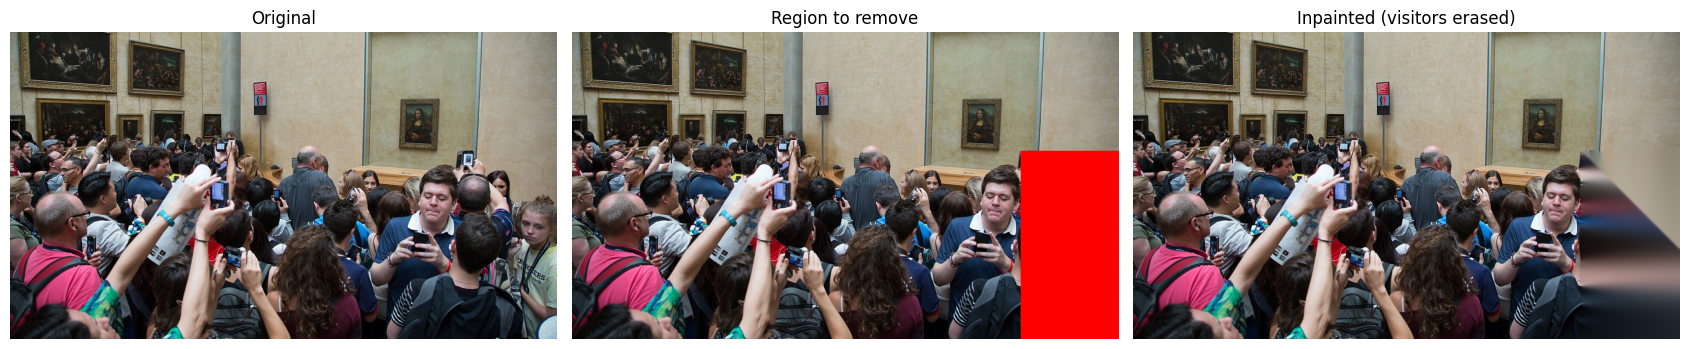

saved ../data/fakes/louvre_inpainted.jpg


In [4]:
louvre = load_rgb("louvre_crowd.jpg")

# Mask two visitors on the right (hand-drawn rectangles for the demo)
mask = np.zeros(louvre.shape[:2], dtype=np.uint8)
cv2.rectangle(mask, (1050, 280), (1280, 720), 255, -1)

removed = cv2.inpaint(louvre, mask, inpaintRadius=7, flags=cv2.INPAINT_TELEA)

fig, axes = plt.subplots(1, 3, figsize=(17, 4.5))
for ax, (im, title) in zip(axes, [
        (louvre, "Original"),
        (np.where(mask[..., None] > 0, np.array([255, 0, 0]), louvre).astype(np.uint8),
         "Region to remove"),
        (removed, "Inpainted (visitors erased)")]):
    ax.imshow(im); ax.set_title(title); ax.axis("off")
plt.tight_layout(); plt.show()

save_fake(removed, "louvre_inpainted.jpg")

Classic inpainting smears; AI inpainting (diffusion-based, §5) *invents*
plausible content. Historical precedent: Stalin-era photo retouching
removed purged officials from official photographs — object removal as a
political act. Every "cleanup" of a heritage photo is also an
interpretation.

## 4. GANs: two networks playing forger and detective

A **Generative Adversarial Network** (Goodfellow, 2014) trains two networks
against each other:

- The **Generator** is the *forger*: it turns random noise into images
- The **Discriminator** is the *detective*: it learns to tell real from fake

Each round, the forger gets better at fooling the detective, and the
detective gets better at catching the forger — until the fakes become
indistinguishable. This produced the famous "this person does not exist"
faces and, in 2018, *Portrait of Edmond de Belamy* — a GAN-generated
painting auctioned at Christie's for $432,500.

The cell below trains a **tiny GAN from scratch** on handwritten digits so
you can *watch a forger learn*. (~3–5 minutes; optional but worth it.)

In [5]:
import torch
import torch.nn as nn
from torchvision import datasets as tv_datasets
from torchvision import transforms as tv_transforms

device = ("mps" if torch.backends.mps.is_available()
          else "cuda" if torch.cuda.is_available() else "cpu")

mnist = tv_datasets.MNIST(root="../data", train=True, download=True,
                          transform=tv_transforms.Compose([
                              tv_transforms.ToTensor(),
                              tv_transforms.Normalize([0.5], [0.5])]))
loader = torch.utils.data.DataLoader(mnist, batch_size=256, shuffle=True)

LATENT = 64
generator = nn.Sequential(
    nn.Linear(LATENT, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 512), nn.LeakyReLU(0.2),
    nn.Linear(512, 28 * 28), nn.Tanh()).to(device)
discriminator = nn.Sequential(
    nn.Linear(28 * 28, 512), nn.LeakyReLU(0.2),
    nn.Linear(512, 256), nn.LeakyReLU(0.2),
    nn.Linear(256, 1)).to(device)

g_opt = torch.optim.Adam(generator.parameters(), lr=2e-4)
d_opt = torch.optim.Adam(discriminator.parameters(), lr=2e-4)
bce = nn.BCEWithLogitsLoss()
fixed_noise = torch.randn(16, LATENT, device=device)
snapshots = []

EPOCHS = 3
for epoch in range(EPOCHS):
    for real, _ in loader:
        real = real.view(real.size(0), -1).to(device)
        noise = torch.randn(real.size(0), LATENT, device=device)
        fake_imgs = generator(noise)

        # Detective's turn: learn to score real high, fake low
        d_opt.zero_grad()
        d_loss = (bce(discriminator(real), torch.ones(real.size(0), 1, device=device)) +
                  bce(discriminator(fake_imgs.detach()),
                      torch.zeros(real.size(0), 1, device=device)))
        d_loss.backward(); d_opt.step()

        # Forger's turn: learn to make the detective say "real"
        g_opt.zero_grad()
        g_loss = bce(discriminator(fake_imgs),
                     torch.ones(real.size(0), 1, device=device))
        g_loss.backward(); g_opt.step()

    with torch.no_grad():
        snapshots.append(generator(fixed_noise).view(16, 28, 28).cpu())
    print(f"epoch {epoch + 1}/{EPOCHS}  forger loss {g_loss.item():.2f}  "
          f"detective loss {d_loss.item():.2f}")

epoch 1/3  forger loss 3.36  detective loss 0.22
epoch 2/3  forger loss 4.03  detective loss 0.15
epoch 3/3  forger loss 3.49  detective loss 0.87


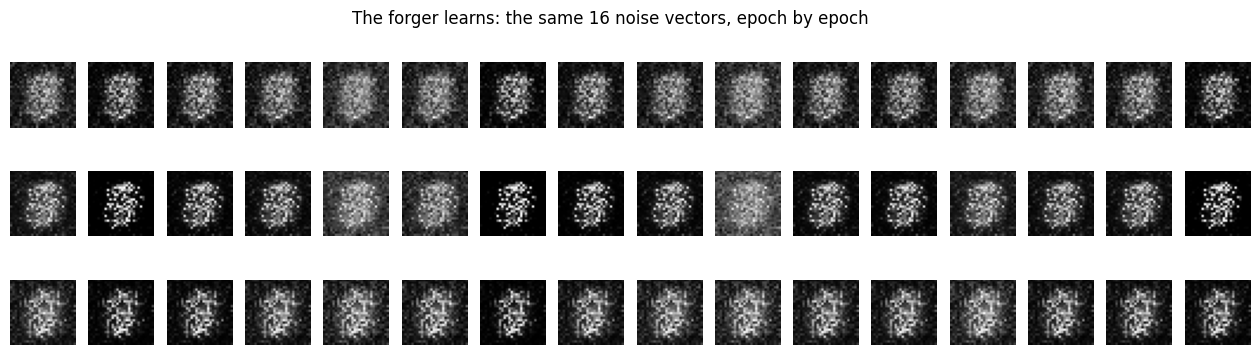

In [6]:
fig, axes = plt.subplots(EPOCHS, 16, figsize=(16, EPOCHS + 1))
for row, snap in enumerate(snapshots):
    for col in range(16):
        ax = axes[row, col] if EPOCHS > 1 else axes[col]
        ax.imshow(snap[col], cmap="gray"); ax.axis("off")
        if col == 0:
            ax.set_ylabel(f"epoch {row + 1}", rotation=0, labelpad=30, fontsize=10)
plt.suptitle("The forger learns: the same 16 noise vectors, epoch by epoch")
plt.show()

From pure noise to recognizable digits in minutes. Scale this idea up
(bigger networks, millions of art images, weeks of GPU time) and you get
photorealistic faces and paintings.

## 5. Diffusion models: image generation from text

Since ~2022, **diffusion models** (Stable Diffusion, DALL·E, Midjourney,
Firefly) have replaced GANs as the leading generators. They learn to
gradually turn noise into an image, *guided by a text description*.

The cell below runs a small open-source Stable Diffusion variant
**locally** — no API key, but it downloads ~1 GB once and takes a couple of
minutes per image on a laptop. Skip it if pressed for time; pre-generated
output is saved to `data/fakes/` either way when it runs.

Cannot initialize model with low cpu memory usage because `accelerate` was not found in the environment. Defaulting to `low_cpu_mem_usage=False`. It is strongly recommended to install `accelerate` for faster and less memory-intense model loading. You can do so with: 
```
pip install accelerate
```
.
Loading pipeline components...:  40%|████      | 2/5 [00:00<00:00,  5.78it/s]An error occurred while trying to fetch /Users/xkaria/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae: Error no file named diffusion_pytorch_model.safetensors found in directory /Users/xkaria/.cache/huggingface/hub/models--segmind--tiny-sd/snapshots/cad0bd7495fa6c4bcca01b19a723dc91627fe84f/vae.
Defaulting to unsafe serialization. Pass `allow_pickle=False` to raise an error instead.
Loading pipeline components...:  80%|████████  | 4/5 [00:00<00:00,  4.26it/s]An error occurred while trying to fetch /Users/xkaria/.cache/huggingface/hub/models--segmind--tiny-sd/sna

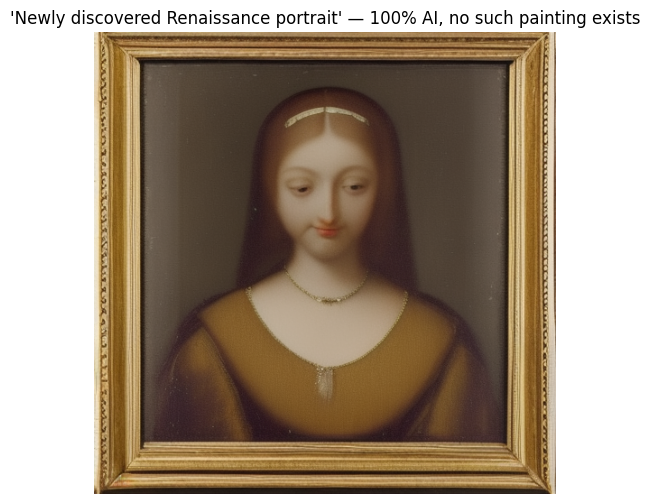

saved ../data/fakes/ai_renaissance_portrait.jpg


In [11]:
RUN_DIFFUSION = True   # set False to skip the heavy cell

if RUN_DIFFUSION:
    from diffusers import StableDiffusionPipeline

    pipe = StableDiffusionPipeline.from_pretrained(
        "segmind/tiny-sd",
        torch_dtype=torch.float32,
        safety_checker=None,        # tiny model; keep the demo lightweight
    ).to(device)

    prompt = ("a newly discovered Renaissance oil painting, portrait of a "
              "young woman with a pearl necklace, cracked varnish, museum "
              "photography, gilded frame")
    result = pipe(prompt, num_inference_steps=30,
                  generator=torch.Generator(device).manual_seed(7))
    ai_painting = result.images[0]

    plt.figure(figsize=(6, 6))
    plt.imshow(ai_painting); plt.axis("off")
    plt.title("'Newly discovered Renaissance portrait' — 100% AI, no such painting exists")
    plt.show()

    ai_painting.save(FAKES / "ai_renaissance_portrait.jpg", quality=92)
    print("saved", FAKES / "ai_renaissance_portrait.jpg")

With a larger model (SDXL, FLUX, Midjourney, GPT-image) the result is
good enough to fool non-experts — and such images **already circulate**:
fake "leaked photos" of artifacts, AI-invented "lost van Goghs" sold as
prints, fabricated war-damage photos of heritage sites.

### Where commercial tools fit
The same generation (and far better quality) is available through APIs and
apps (DALL·E/GPT-image, Midjourney, Adobe Firefly). Two professional notes:
- **Provenance standards**: Adobe & others embed *Content Credentials*
  (C2PA) — cryptographic metadata recording AI involvement. Museums are
  early adopters of this standard. We'll inspect metadata in Notebook 6.
- **Copyright** of AI-generated images is unsettled law in most
  jurisdictions — a real concern for museum publishing.

## ⚖️ Discussion: legitimate vs. malicious — where's the line?

| Use | Same technology, different ethics |
|---|---|
| Reconstructing the destroyed Buddhas of Bamiyan for an exhibit | ✅ disclosed reconstruction |
| Colorizing archival photos, labeled as colorized | ✅ disclosed enhancement |
| "Restoring" a damaged painting in the catalog photo, undisclosed | ⚠️ misleading documentation |
| Generating a "photo" proving a forged artwork's provenance | ❌ fraud |

The recurring principle: **disclosure**. Manipulation isn't inherently
wrong; *hidden* manipulation is.

## ✏️ Exercises

1. Create your own copy–move forgery from any sample image and save it to
   `data/fakes/` — you'll test detectors against it in Notebook 6.
2. Change the diffusion prompt to fabricate an "archaeological discovery"
   photo. What gives it away to your eye? Make a list — then check that
   list against the detectors in Notebook 6.
3. Watch the GAN snapshots again: what do digits look like when the
   forger is "half-trained"? Do AI image artifacts (hands, text, ears)
   have an equivalent today?
4. Find a real case of image-based heritage disinformation (news, fact-
   checking sites) and present: what was faked, how was it exposed?

**Next:** Notebook 6 — the detective's toolkit: catching every fake we
just made.